In [ ]:
# SISTEMA DE RECOMENDAÇÃO DE ARTIGOS CIENTÍFICOS - OpenAlex
# Metodologia: Filtragem por Conteúdo com TF-IDF + Cosseno
# Versão:3.0
# Ambiente: Google Colab

In [ ]:
# ============================================================
# INSTALAÇÃO (execute antes se necessário) e IMPORTS
# ============================================================
# Descomente a linha abaixo se precisar instalar as bibliotecas
# !pip install requests scikit-learn pandas numpy

import requests
import pandas as pd
import numpy as np
import re
import time

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize

In [ ]:
# ============================================================
# ETAPA 1 — FUNÇÃO PARA RECONSTRUIR ABSTRACT
# ============================================================

def reconstruir_abstract(inverted_index):
    if not inverted_index or not isinstance(inverted_index, dict):
        return ""

    pares = []
    for palavra, posicoes in inverted_index.items():
        for pos in posicoes:
            pares.append((pos, palavra))

    pares.sort(key=lambda x: x[0])
    return " ".join(p for _, p in pares)

In [ ]:
# ============================================================
# ETAPA 2 — COLETA DE DADOS OPENALEX
# ============================================================

def coletar_artigos_openalex(conceitos, anos=(2020, 2024), meta_total=1000):
    BASE_URL = "https://api.openalex.org/works"
    MAILTO = "slthaina@outlook.com"
    registros = []
    ids_vistos = set()

    print("=" * 70)
    print("INICIANDO COLETA")
    print("=" * 70)
    print(f"Meta: {meta_total} artigos")
    print(f"Período: {anos[0]}–{anos[1]}")
    print(f"Total de conceitos: {len(conceitos)}\n")

    for conceito in conceitos:
        print(f"→ Coletando: {conceito}")
        cursor = "*"
        paginas = 0
        artigos_conceito = 0

        while True:
            params = {
                "search": conceito,
                "filter": (
                    f"from_publication_date:{anos[0]}-01-01,"
                    f"to_publication_date:{anos[1]}-12-31,"
                    "has_abstract:true"
                ),
                "select": (
                    "id,title,abstract_inverted_index,publication_year,authorships,primary_location,concepts"
                ),
                "sort": "cited_by_count:desc",
                "per-page": 200,
                "cursor": cursor,
                "mailto": MAILTO,
            }

            try:
                resposta = requests.get(BASE_URL, params=params, timeout=30)
                resposta.raise_for_status()
                dados = resposta.json()
            except requests.exceptions.RequestException as e:
                print(f"[ERRO] {e}")
                break

            resultados = dados.get("results", [])
            if not resultados:
                break

            for obra in resultados:
                obra_id = obra.get("id", "")
                if obra_id in ids_vistos:
                    continue

                ids_vistos.add(obra_id)
                titulo = obra.get("title") or ""
                abstract = reconstruir_abstract(obra.get("abstract_inverted_index"))

                if not titulo.strip() or not abstract.strip():
                    continue

                ano = obra.get("publication_year")
                autores = ", ".join(
                    a.get("author", {}).get("display_name", "")
                    for a in (obra.get("authorships") or [])
                    if a.get("author", {}).get("display_name")
                )

                conceitos_obra = ", ".join(
                    c.get("display_name", "")
                    for c in (obra.get("concepts") or [])[:5]
                )

                loc = obra.get("primary_location") or {}
                doi = loc.get("landing_page_url") or obra_id

                registros.append({
                    "titulo": titulo,
                    "autores": autores,
                    "resumo": abstract,
                    "ano": ano,
                    "openalex_id": obra_id,
                    "doi": doi,
                    "conceitos_api": conceitos_obra,
                })

                artigos_conceito += 1

            paginas += 1
            if paginas % 2 == 0:
                print(f"Página {paginas} | Total acumulado: {len(registros)}")

            if len(registros) >= meta_total:
                break

            meta = dados.get("meta", {})
            cursor = meta.get("next_cursor")
            if not cursor:
                break

            time.sleep(0.5)

        print(f"✔ Artigos coletados: {artigos_conceito}\n")
        if len(registros) >= meta_total:
            print("✔ Meta atingida.\n")
            break

    colunas = ["titulo", "autores", "resumo", "ano", "openalex_id", "doi", "conceitos_api"]
    df = pd.DataFrame(registros, columns=colunas)
    df = df.head(meta_total)

    print("=" * 70)
    print(f"✔ TOTAL FINAL: {len(df)} artigos")
    print("=" * 70)

    return df

In [ ]:
# ============================================================
# CONFIGURAÇÕES E EXECUÇÃO
# ============================================================

CONCEITOS_OPENALEX = [
    "Climate change", "Sustainability", "Environmental science",
    "Renewable energy", "Biodiversity", "Deforestation",
    "Greenhouse gas", "Ocean acidification", "Water scarcity", "Wildfire",
]

ANO_INICIO = 2020
ANO_FIM = 2024
META_TOTAL = 1000

# Execução
df_raw = coletar_artigos_openalex(
    CONCEITOS_OPENALEX,
    anos=(ANO_INICIO, ANO_FIM),
    meta_total=META_TOTAL
)

# Verificação e Salvamento
if df_raw.empty:
    raise ValueError("\n[ERRO] Nenhum artigo foi coletado.")

df_raw.to_csv("dataset_bruto_openalex.csv", index=False)
print("\n✔ Dataset bruto salvo.")

INICIANDO COLETA
Meta: 1000 artigos
Período: 2020–2024
Total de conceitos: 10

→ Coletando: Climate change
Página 2 | Total acumulado: 400
Página 4 | Total acumulado: 800
✔ Artigos coletados: 1000

✔ Meta atingida.

✔ TOTAL FINAL: 1000 artigos

✔ Dataset bruto salvo.


In [ ]:
# ============================================================
# ETAPA 3 — PRÉ-PROCESSAMENTO
# ============================================================

STOPWORDS_EN = {
    "a","an","the","and","or","but","if","in","on","at","to","for","of",
    "with","by","from","as","is","was","are","were","be","been","being",
    "have","has","had","do","does","did","will","would","could","should",
    "may","might","shall","can","not","no","nor","so","yet","both",
    "either","neither","each","few","more","most","other","some",
    "such","than","then","that","this","these","those","which","who",
    "whom","what","when","where","why","how","all","any","he","she",
    "it","we","they","i","you","his","her","its","our","their","my",
    "your","up","out","about","into","through","during","before",
    "after","above","below","between","among","while","although",
    "because","since","there","here","very","just","also","only",
    "over","under","again","further","once","per","via"
}

STOPWORDS_CUSTOM = {
    "model","method","study","analysis","approach",
    "result","results","paper","proposed","using",
    "used","use","show","shown","shows","present",
    "presented","data","dataset","performance",
    "system","framework","task","tasks","work",
    "works","new","novel","evaluation","experiment",
    "experiments","baseline","large","high","low"
}

TODAS_STOPWORDS = STOPWORDS_EN | STOPWORDS_CUSTOM

def preprocessar_texto(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in TODAS_STOPWORDS and len(t) >= 3]
    return " ".join(tokens)

print("\n" + "=" * 70)
print("PRÉ-PROCESSAMENTO")
print("=" * 70)

df = df_raw.dropna(subset=["titulo", "resumo"]).copy()
print(f"✔ Registros válidos: {len(df)}")

df["titulo_limpo"] = df["titulo"].apply(preprocessar_texto)
df["resumo_limpo"] = df["resumo"].apply(preprocessar_texto)

print("✔ Pré-processamento concluído.")


PRÉ-PROCESSAMENTO
✔ Registros válidos: 1000
✔ Pré-processamento concluído.


In [ ]:
# ============================================================
# ETAPA 4 — FILTRAGEM TEMÁTICA
# ============================================================

TERMOS_FORTES = {
    "climate change", "global warming", "carbon emissions",
    "greenhouse gas", "biodiversity loss", "deforestation",
    "ocean acidification", "wildfire", "water scarcity", "renewable energy",
}

TERMOS_MEDIOS = {
    "environment", "environmental", "energy", "ecosystem",
    "ecological", "pollution", "sustainability", "renewable",
    "conservation", "biodiversity", "forest", "marine", "climate",
}

def eh_relevante(titulo, resumo):
    texto = f"{titulo} {resumo}".lower()

    for t in TERMOS_FORTES:
        if t in texto:
            return True

    contagem_media = sum(1 for t in TERMOS_MEDIOS if t in texto)
    if contagem_media >= 2:
        return True

    return False

print("\n" + "=" * 70)
print("FILTRAGEM TEMÁTICA")
print("=" * 70)

df["relevante"] = df.apply(lambda r: eh_relevante(r["titulo"], r["resumo"]), axis=1)
df_filtrado = df[df["relevante"]].copy().reset_index(drop=True)

print(f"✔ Antes da filtragem: {len(df)}")
print(f"✔ Após filtragem: {len(df_filtrado)}")

if df_filtrado.empty:
    raise ValueError("[ERRO] Dataset vazio após filtragem.")

print("\nDistribuição por ano:\n")
dist_ano = df_filtrado["ano"].value_counts().sort_index()

for ano, qtd in dist_ano.items():
    barra = "█" * (qtd // 5)
    print(f"{int(ano)}: {qtd:>4} {barra}")


FILTRAGEM TEMÁTICA
✔ Antes da filtragem: 1000
✔ Após filtragem: 569

Distribuição por ano:

2020:  257 ███████████████████████████████████████████████████
2021:  153 ██████████████████████████████
2022:   80 ████████████████
2023:   69 █████████████
2024:   10 ██


In [ ]:
# ============================================================
# ETAPA 5 — TF-IDF E ETAPA 6 — SIMILARIDADE
# ============================================================

def construir_texto_ponderado(titulo_limpo, resumo_limpo, peso_titulo=3):
    titulo_rep = " ".join([titulo_limpo] * peso_titulo)
    return f"{titulo_rep} {resumo_limpo}"

print("\n" + "=" * 70)
print("TF-IDF E SIMILARIDADE")
print("=" * 70)

df_filtrado["texto_final"] = df_filtrado.apply(
    lambda r: construir_texto_ponderado(r["titulo_limpo"], r["resumo_limpo"]), axis=1
)

vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
matriz_tfidf = vectorizer.fit_transform(df_filtrado["texto_final"])
matriz_tfidf_norm = normalize(matriz_tfidf, norm="l2")

print(f"✔ Matriz TF-IDF: {matriz_tfidf_norm.shape[0]} artigos × {matriz_tfidf_norm.shape[1]} features")

matriz_similaridade = cosine_similarity(matriz_tfidf_norm)
print(f"✔ Matriz de Similaridade: {matriz_similaridade.shape}")

sim_sem_diagonal = matriz_similaridade[~np.eye(matriz_similaridade.shape[0], dtype=bool)]
print(f"✔ Similaridade média: {sim_sem_diagonal.mean():.4f}")


TF-IDF E SIMILARIDADE
✔ Matriz TF-IDF: 569 artigos × 5000 features
✔ Matriz de Similaridade: (569, 569)
✔ Similaridade média: 0.0333


In [ ]:
# ============================================================
# ETAPA 7 — RECOMENDAÇÃO
# ============================================================

SCORE_MINIMO = 0.10

def recomendar_por_indice(indice, top_n=5):
    scores = list(enumerate(matriz_similaridade[indice]))
    scores = sorted(scores, key=lambda x: x[1], reverse=True)
    scores = [(i, s) for i, s in scores if i != indice and s >= SCORE_MINIMO][:top_n]

    recomendacoes = []
    for idx, score in scores:
        recomendacoes.append({
            "titulo": df_filtrado.iloc[idx]["titulo"],
            "similaridade": round(score, 4),
            "ano": df_filtrado.iloc[idx]["ano"],
        })

    return pd.DataFrame(recomendacoes)

def recomendar_por_titulo(titulo_parcial, top_n=5):
    mascara = df_filtrado["titulo"].str.lower().str.contains(titulo_parcial.lower(), na=False)
    encontrados = df_filtrado[mascara]

    if encontrados.empty:
        print(f"Nenhum artigo encontrado para '{titulo_parcial}'.")
        return pd.DataFrame()

    indice = encontrados.index[0]
    print(f"\nArtigo base:\n{df_filtrado.iloc[indice]['titulo']}\n")

    return recomendar_por_indice(indice, top_n)

In [ ]:
# ============================================================
# TESTES E SALVAR DATASET FINAL
# ============================================================

print("\n" + "=" * 70)
print("TESTES")
print("=" * 70)

print("\n[ Recomendações para 'renewable' ]")
rec = recomendar_por_titulo("renewable", top_n=5)
if not rec.empty:
    print(rec.to_string(index=False))

print("\n[ Recomendações para 'biodiversity' ]")
rec2 = recomendar_por_titulo("biodiversity", top_n=5)
if not rec2.empty:
    print(rec2.to_string(index=False))

# Salvar
df_filtrado.to_csv("dataset_filtrado_openalex.csv", index=False)
print("\n✔ Dataset filtrado salvo.")

print("\n" + "=" * 70)
print("PIPELINE CONCLUÍDO COM SUCESSO")
print("=" * 70)

print(f"✔ Artigos finais: {len(df_filtrado)}")
print(f"✔ Features TF-IDF: {matriz_tfidf_norm.shape[1]}")
print(f"✔ Matriz similaridade: {matriz_similaridade.shape}")


TESTES

[ Recomendações para 'renewable' ]

Artigo base:
A Global Assessment: Can Renewable Energy Replace Fossil Fuels by 2050?

                                                                                                                                     titulo  similaridade  ano
                                                        Role of energy storage systems in energy transition from fossil fuels to renewables        0.2505 2020
A Comprehensive Review on Renewable Energy Development, Challenges, and Policies of Leading Indian States With an International Perspective        0.1938 2020
                                                                                                Renewable Energy and Energy Storage Systems        0.1922 2023
                              The mitigating effects of economic complexity and renewable energy on carbon emissions in developed countries        0.1888 2020
                                          Sustainable Energy Transition fo

In [ ]:
# VISUALIZAÇÕES DO SISTEMA DE RECOMENDAÇÃO - OpenAlex
# Ambiente: Google Colab

In [ ]:
# ============================================================
# INSTALAÇÃO (execute antes se necessário) e IMPORTS
# ============================================================
# Descomente a linha abaixo se precisar instalar as bibliotecas
# !pip install pandas numpy matplotlib seaborn scikit-learn wordcloud

import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from wordcloud import WordCloud
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
from sklearn.decomposition import PCA

In [ ]:
# ============================================================
# ESTILO VISUAL E PASTA DE SAÍDA
# ============================================================

VERDE_ESCURO = "#1B4332"
VERDE_MEDIO  = "#2D6A4F"
VERDE_CLARO  = "#52B788"
VERDE_PALIDO = "#B7E4C7"

FUNDO    = "#F8FAF9"
TEXTO    = "#1C1C1C"
DESTAQUE = "#D62828"

plt.rcParams.update({
    "figure.facecolor": FUNDO,
    "axes.facecolor": FUNDO,
    "axes.edgecolor": VERDE_ESCURO,
    "axes.labelcolor": TEXTO,
    "xtick.color": TEXTO,
    "ytick.color": TEXTO,
    "text.color": TEXTO,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.color": VERDE_PALIDO,
    "grid.linewidth": 0.6,
    "grid.alpha": 0.7,
})

PASTA_SAIDA = "graficos_openalex"
os.makedirs(PASTA_SAIDA, exist_ok=True)

def salvar(fig, nome):
    caminho = f"{PASTA_SAIDA}/{nome}.png"
    fig.savefig(caminho, dpi=200, bbox_inches="tight", facecolor=FUNDO)
    print(f"✔ Salvo: {caminho}")
    plt.show()
    plt.close(fig)

In [ ]:
# ============================================================
# CARREGAMENTO E LIMPEZA DE TEXTO
# ============================================================

print("=" * 65)
print("CARREGANDO DATASET")
print("=" * 65)

# Certifique-se de que o arquivo gerado no script anterior esteja na pasta
df = pd.read_csv("dataset_filtrado_openalex.csv")
print(f"✔ Artigos carregados: {len(df)}")

STOPWORDS_EN = {
    "a","an","the","and","or","but","if","in","on","at","to","for","of",
    "with","by","from","as","is","was","are","were","be","been","being",
    "have","has","had","do","does","did","will","would","could","should",
    "may","might","shall","can","not","no","nor","so","yet","both","either",
    "neither","each","few","more","most","other","some","such","than","then",
    "that","this","these","those","which","who","whom","what","when","where",
    "why","how","all","any","both","he","she","it","we","they","i","you",
    "his","her","its","our","their","my","your","up","out","about","into",
    "through","during","before","after","above","below","between","among",
    "while","although","because","since","there","here","very","just","also",
    "only","over","under","again","further","once","per","via","re","eg",
    "ie","etc",
}

STOPWORDS_CUSTOM = {
    "model","method","study","analysis","approach","result","results",
    "paper","proposed","based","using","used","use","show","shown",
    "shows","present","presented","presents","data","dataset",
    "performance","system","framework","task","tasks","work",
    "works","new","novel","existing","state","art","two","three",
    "four","five","one","first","second","third","evaluation",
    "experiment","experiments","experimental","baseline","large",
    "high","low","well","however","thus","therefore","hence",
    "fig","table","et","al","section","propose","provides",
    "provide","able","different","various","several","recent",
    "current","previous","following","given","set","sets",
    "number","numbers","type","types","level","levels","case","cases",
}

TODAS_SW = STOPWORDS_EN | STOPWORDS_CUSTOM

def limpar(texto):
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r"[^a-z\s]", " ", texto)
    tokens = texto.split()
    tokens = [t for t in tokens if t not in TODAS_SW and len(t) >= 3]
    return " ".join(tokens)

# Garante colunas limpas
if "titulo_limpo" not in df.columns:
    df["titulo_limpo"] = df["titulo"].apply(limpar)

if "resumo_limpo" not in df.columns:
    df["resumo_limpo"] = df["resumo"].apply(limpar)

def construir_texto(row):
    titulo = row["titulo_limpo"]
    resumo = row["resumo_limpo"]
    titulo_ponderado = " ".join([titulo] * 3)
    return f"{titulo_ponderado} {resumo}"

df["texto_final"] = df.apply(construir_texto, axis=1)

CARREGANDO DATASET
✔ Artigos carregados: 569


In [ ]:
# ============================================================
# TF-IDF + SIMILARIDADE
# ============================================================

print("\n" + "=" * 65)
print("RECONSTRUINDO TF-IDF")
print("=" * 65)

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    sublinear_tf=True,
)

tfidf = vectorizer.fit_transform(df["texto_final"])
tfidf_norm = normalize(tfidf, norm="l2")
matriz_sim = cosine_similarity(tfidf_norm)

print(f"✔ TF-IDF: {tfidf_norm.shape}")
print(f"✔ Similaridade: {matriz_sim.shape}")


RECONSTRUINDO TF-IDF
✔ TF-IDF: (569, 5000)
✔ Similaridade: (569, 569)



[1] Distribuição por ano
✔ Salvo: graficos_openalex/01_distribuicao_por_ano.png


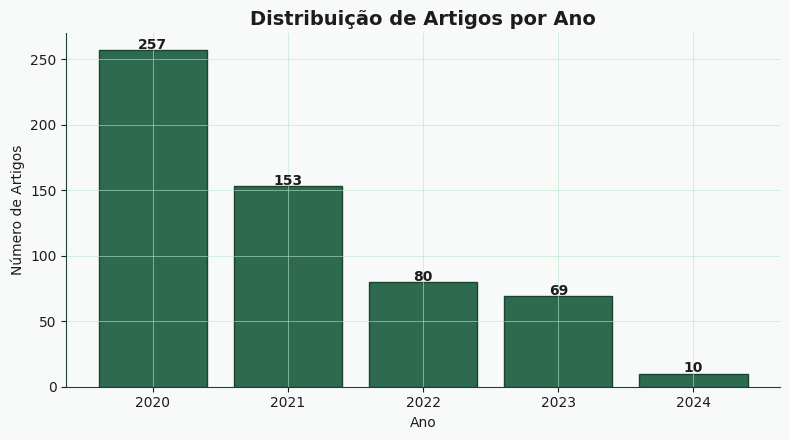


[2] Top palavras
✔ Salvo: graficos_openalex/02_top20_palavras.png


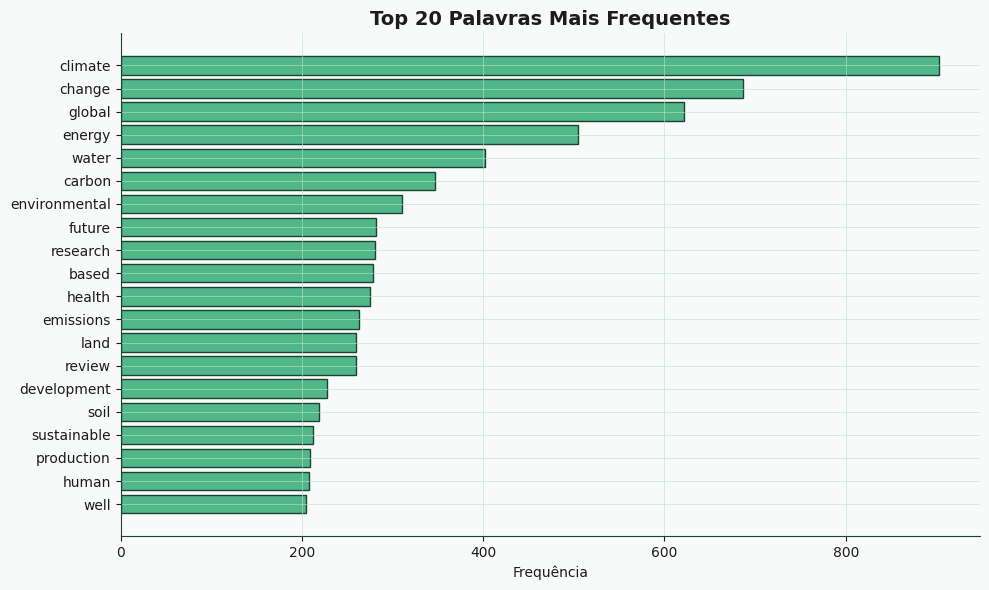


[3] Wordcloud títulos
✔ Salvo: graficos_openalex/03_wordcloud_titulos.png


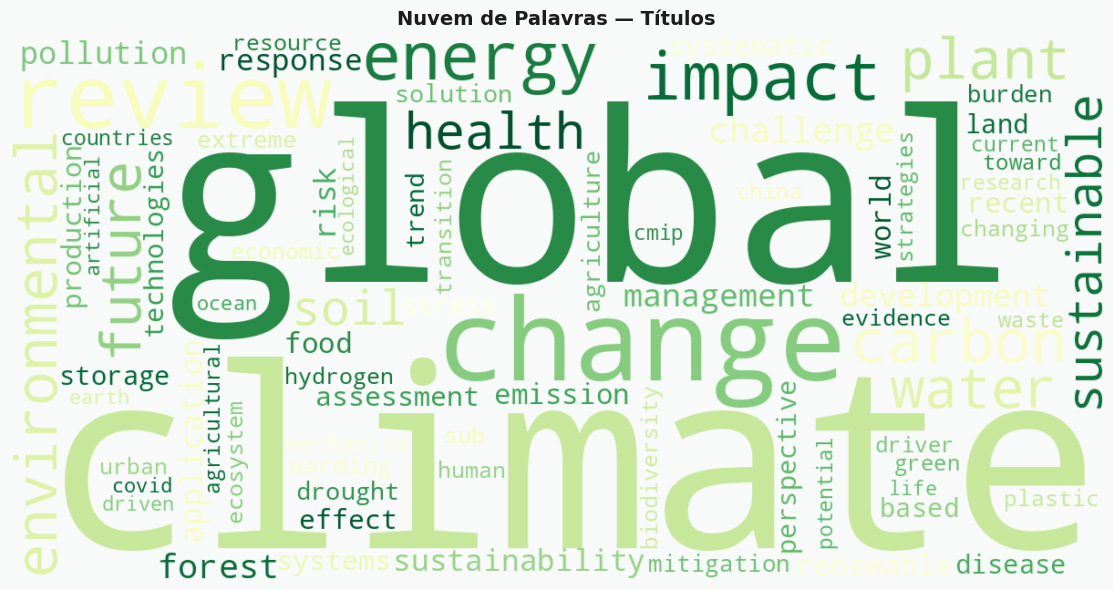


[4] Wordcloud resumos
✔ Salvo: graficos_openalex/04_wordcloud_resumos.png


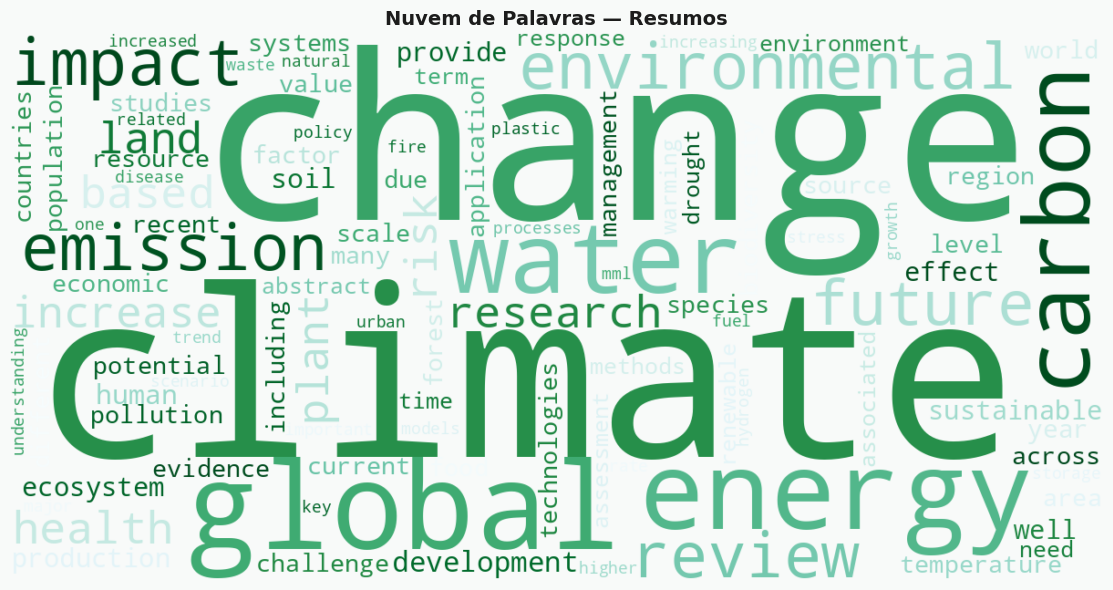

In [ ]:
# ============================================================
# GRÁFICOS [1] a [4]
# ============================================================

# [1] DISTRIBUIÇÃO POR ANO
print("\n[1] Distribuição por ano")
dist_ano = df["ano"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(8, 4.5))
bars = ax.bar(dist_ano.index.astype(str), dist_ano.values, color=VERDE_MEDIO, edgecolor=VERDE_ESCURO)

for bar, valor in zip(bars, dist_ano.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, str(valor), ha="center", fontsize=10, fontweight="bold")

ax.set_title("Distribuição de Artigos por Ano", fontsize=14, fontweight="bold")
ax.set_xlabel("Ano")
ax.set_ylabel("Número de Artigos")
fig.tight_layout()
salvar(fig, "01_distribuicao_por_ano")

# [2] TOP 20 PALAVRAS
print("\n[2] Top palavras")
tokens = " ".join(df["resumo_limpo"]).split()
freq = Counter(tokens).most_common(20)
palavras = [x[0] for x in freq]
contagens = [x[1] for x in freq]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(list(reversed(palavras)), list(reversed(contagens)), color=VERDE_CLARO, edgecolor=VERDE_ESCURO)
ax.set_title("Top 20 Palavras Mais Frequentes", fontsize=14, fontweight="bold")
ax.set_xlabel("Frequência")
fig.tight_layout()
salvar(fig, "02_top20_palavras")

# [3] NUVEM DE PALAVRAS — TÍTULOS
print("\n[3] Wordcloud títulos")
texto_titulos = " ".join(df["titulo_limpo"])
wc_titulos = WordCloud(width=1200, height=600, background_color=FUNDO, colormap="YlGn", max_words=80, collocations=False).generate(texto_titulos)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_titulos, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nuvem de Palavras — Títulos", fontsize=14, fontweight="bold")
fig.tight_layout()
salvar(fig, "03_wordcloud_titulos")

# [4] NUVEM DE PALAVRAS — RESUMOS
print("\n[4] Wordcloud resumos")
texto_resumos = " ".join(df["resumo_limpo"])
wc_resumos = WordCloud(width=1200, height=600, background_color=FUNDO, colormap="BuGn", max_words=100, collocations=False).generate(texto_resumos)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wc_resumos, interpolation="bilinear")
ax.axis("off")
ax.set_title("Nuvem de Palavras — Resumos", fontsize=14, fontweight="bold")
fig.tight_layout()
salvar(fig, "04_wordcloud_resumos")


[5] Heatmap
✔ Salvo: graficos_openalex/05_heatmap.png


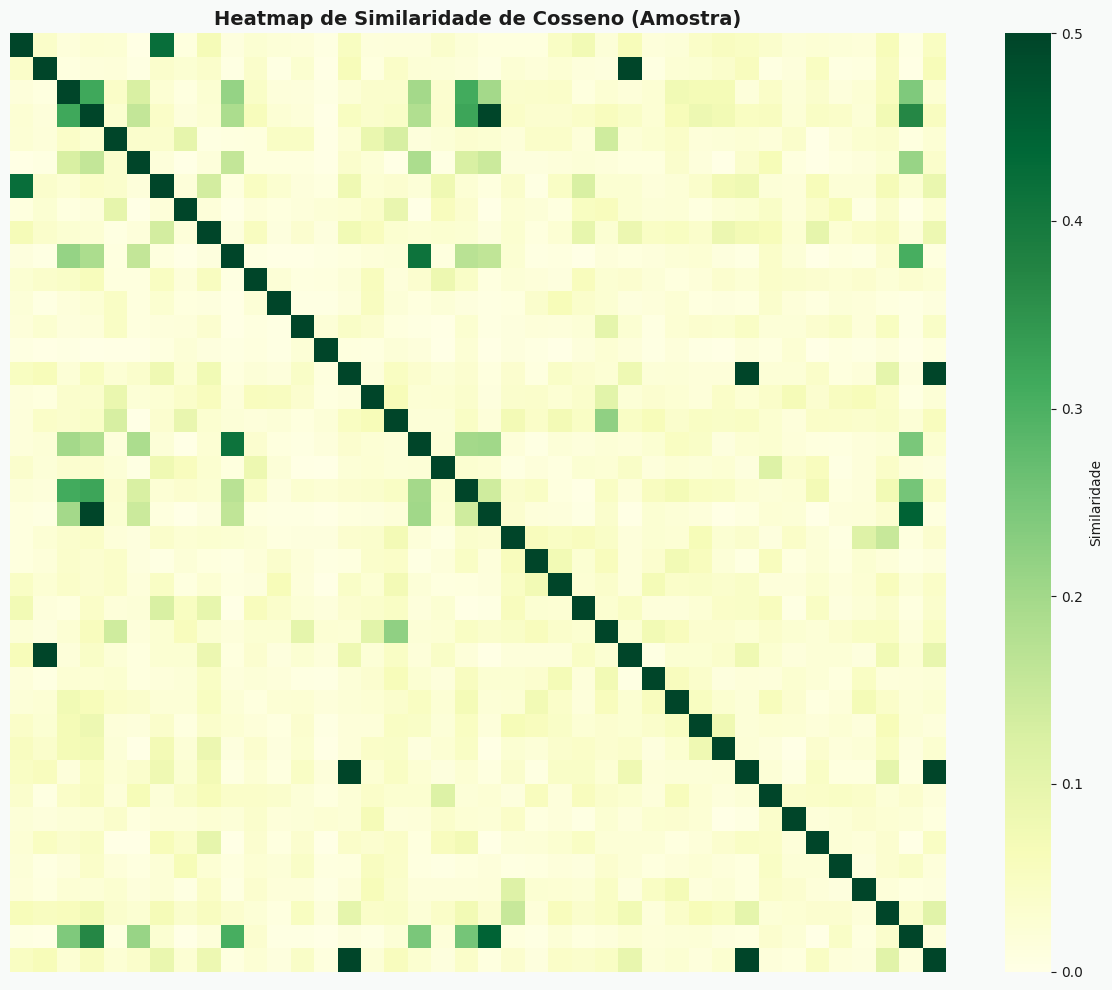


[6] Histograma
✔ Salvo: graficos_openalex/06_histograma_scores.png


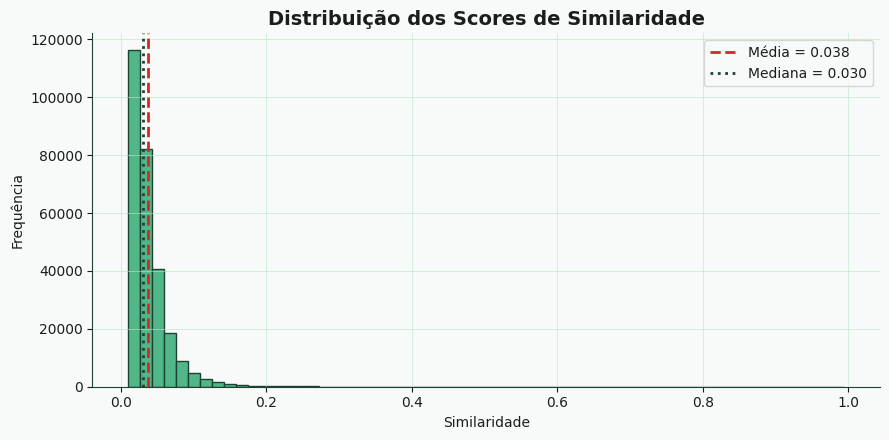


[7] Melhor score por artigo
✔ Salvo: graficos_openalex/07_melhor_score.png


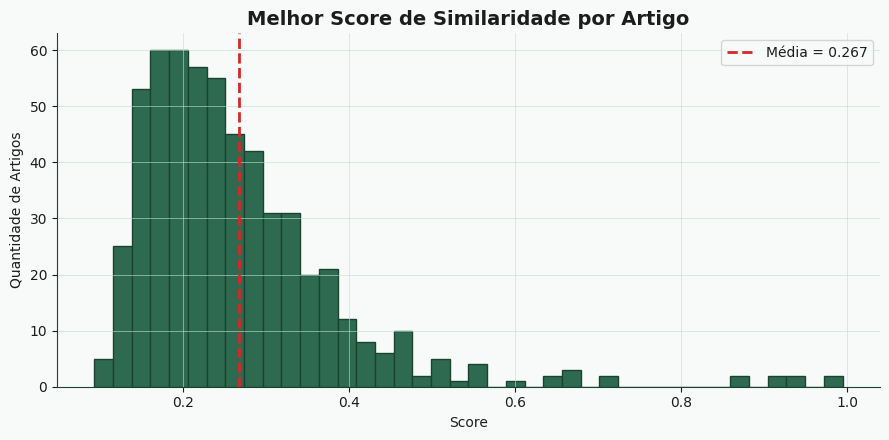

In [ ]:
# ============================================================
# GRÁFICOS [5] a [7]
# ============================================================

# [5] HEATMAP
print("\n[5] Heatmap")
N = min(40, len(df))
amostra = matriz_sim[:N, :N]

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(amostra, cmap="YlGn", vmin=0, vmax=0.5, xticklabels=False, yticklabels=False, cbar_kws={"label": "Similaridade"})
ax.set_title("Heatmap de Similaridade de Cosseno (Amostra)", fontsize=14, fontweight="bold")
fig.tight_layout()
salvar(fig, "05_heatmap")

# [6] HISTOGRAMA DOS SCORES
print("\n[6] Histograma")
mascara = ~np.eye(matriz_sim.shape[0], dtype=bool)
scores = matriz_sim[mascara]
scores = scores[scores > 0.01]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(scores, bins=60, color=VERDE_CLARO, edgecolor=VERDE_ESCURO)
media = scores.mean()
mediana = np.median(scores)

ax.axvline(media, color=DESTAQUE, linestyle="--", linewidth=2, label=f"Média = {media:.3f}")
ax.axvline(mediana, color=VERDE_ESCURO, linestyle=":", linewidth=2, label=f"Mediana = {mediana:.3f}")
ax.legend()
ax.set_title("Distribuição dos Scores de Similaridade", fontsize=14, fontweight="bold")
ax.set_xlabel("Similaridade")
ax.set_ylabel("Frequência")
fig.tight_layout()
salvar(fig, "06_histograma_scores")

# [7] MELHOR SCORE POR ARTIGO
print("\n[7] Melhor score por artigo")
top_scores = []
for i in range(len(df)):
    linha = matriz_sim[i].copy()
    linha[i] = 0
    top_scores.append(linha.max())
top_scores = np.array(top_scores)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(top_scores, bins=40, color=VERDE_MEDIO, edgecolor=VERDE_ESCURO)
ax.axvline(top_scores.mean(), color=DESTAQUE, linestyle="--", linewidth=2, label=f"Média = {top_scores.mean():.3f}")
ax.legend()
ax.set_title("Melhor Score de Similaridade por Artigo", fontsize=14, fontweight="bold")
ax.set_xlabel("Score")
ax.set_ylabel("Quantidade de Artigos")
fig.tight_layout()
salvar(fig, "07_melhor_score")


[8] Top pares
✔ Salvo: graficos_openalex/08_top10_pares.png


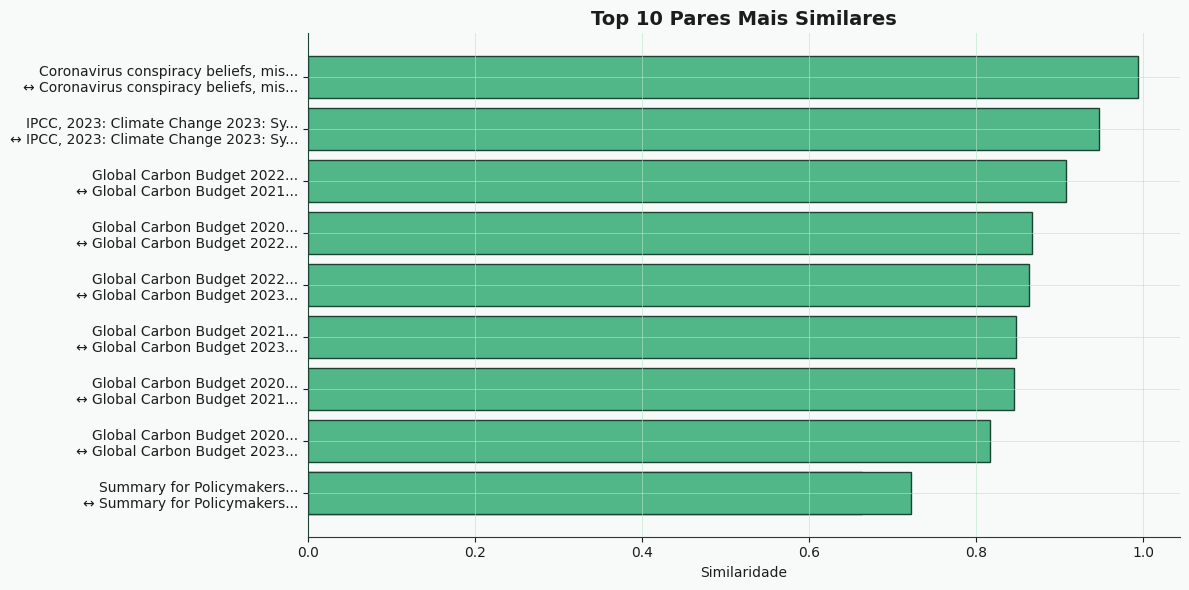


[9] PCA
✔ Salvo: graficos_openalex/09_pca_2d.png


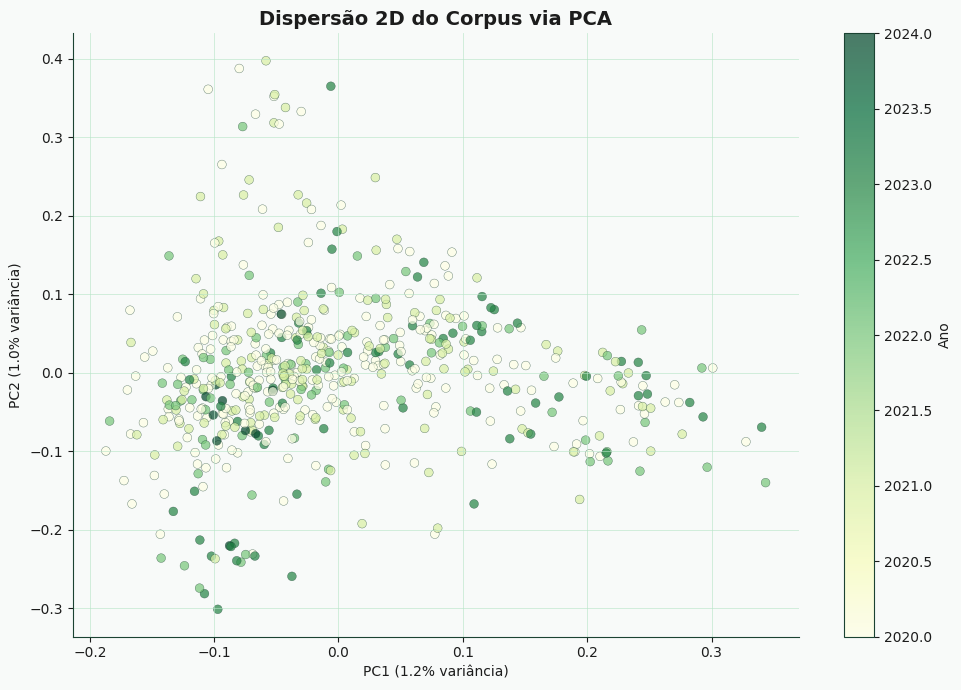


VISUALIZAÇÕES CONCLUÍDAS
✔ Gráficos salvos em: graficos_openalex

Arquivos gerados:

• 01_distribuicao_por_ano.png
• 02_top20_palavras.png
• 03_wordcloud_titulos.png
• 04_wordcloud_resumos.png
• 05_heatmap.png
• 06_histograma_scores.png
• 07_melhor_score.png
• 08_top10_pares.png
• 09_pca_2d.png


In [ ]:
# ============================================================
# GRÁFICOS [8] a [9] E FINALIZAÇÃO
# ============================================================

# [8] TOP 10 PARES MAIS SIMILARES
print("\n[8] Top pares")
pares = []
for i in range(len(df)):
    for j in range(i + 1, len(df)):
        pares.append((matriz_sim[i, j], i, j))
pares.sort(reverse=True)
top10 = pares[:10]

rotulos = []
valores = []
for score, i, j in top10:
    t1 = df.iloc[i]["titulo"][:35]
    t2 = df.iloc[j]["titulo"][:35]
    rotulos.append(f"{t1}...\n↔ {t2}...")
    valores.append(score)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(list(reversed(rotulos)), list(reversed(valores)), color=VERDE_CLARO, edgecolor=VERDE_ESCURO)
ax.set_title("Top 10 Pares Mais Similares", fontsize=14, fontweight="bold")
ax.set_xlabel("Similaridade")
fig.tight_layout()
salvar(fig, "08_top10_pares")

# [9] PCA 2D
print("\n[9] PCA")
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(tfidf_norm.toarray())
variancia = pca.explained_variance_ratio_ * 100

fig, ax = plt.subplots(figsize=(10, 7))
scatter = ax.scatter(
    coords[:, 0], coords[:, 1], c=df["ano"], cmap="YlGn",
    s=40, alpha=0.7, edgecolors=VERDE_ESCURO, linewidths=0.3
)
cbar = fig.colorbar(scatter)
cbar.set_label("Ano")

ax.set_title("Dispersão 2D do Corpus via PCA", fontsize=14, fontweight="bold")
ax.set_xlabel(f"PC1 ({variancia[0]:.1f}% variância)")
ax.set_ylabel(f"PC2 ({variancia[1]:.1f}% variância)")
fig.tight_layout()
salvar(fig, "09_pca_2d")

# ============================================================
# FINAL
# ============================================================
print("\n" + "=" * 65)
print("VISUALIZAÇÕES CONCLUÍDAS")
print("=" * 65)

print(f"✔ Gráficos salvos em: {PASTA_SAIDA}")
print("\nArquivos gerados:\n")
for arq in sorted(os.listdir(PASTA_SAIDA)):
    print(f"• {arq}")